# Introduction

In this notebook, we will simulate **momentum-based trading strategies**. We will use historical stock price data to implement these strategies and evaluate their performance over a specified period.

**Strategies covered:**
1. **Price Momentum** - Moving Average Crossover
2. **RSI Momentum** - Relative Strength Index
3. **MACD Momentum** - Moving Average Convergence Divergence
4. **ROC Momentum** - Rate of Change
5. **Volume-Weighted Momentum** - Price + Volume confirmation
6. **OBV/VPT Momentum** - On-Balance Volume / Volume Price Trend
7. **MFI Momentum** - Money Flow Index
8. **Triple Momentum** - Multi-timeframe momentum
9. **Accelerating Momentum** - Momentum of momentum

Pipeline for an algorithmic trading strategy includes the following steps:
1. **Data Collection**: Gather historical stock price data (we use crawler)
2. **Data Preprocessing**: Clean and preprocess the data 
3. **Strategy Implementation**: Define the rules for momentum strategies
4. **Parameter Optimization**: Find optimal parameters using Optuna
5. **Backtesting**: Simulate the strategies over historical data
6. **Performance Evaluation**: Analyze results using various metrics

---

# Set up 

## Library & Modules

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

In [ ]:
# Import modules
import sys
import os

# Add parent directory to path for imports
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Change working directory to parent so relative paths work
os.chdir(parent_dir)

# Data loading and utilities
from utils import (
    load_historical_data, load_all_historical,
    preprocess_historical_data, check_data_quality, print_data_quality_report,
    calculate_rsi, calculate_macd, calculate_obv, calculate_mfi,
)

# Momentum strategies
from strategies.momentum import (
    PriceMomentum, RSIMomentum, MACDMomentum, ROCMomentum,
    MACDMomentum, VolumeWeightedMomentum, OBVMomentum,
    VPTMomentum, MFIMomentum, TripleMomentum, AcceleratingMomentum,
    MomentumPortfolio, backtest_strategy, compare_strategies
)

print("All modules imported successfully!")

All modules imported successfully!


## Visualization function

In [ ]:
def plot_strategy_analysis(df, result_df, backtest_result, strategy_name, indicator_col=None, indicator_name=None):
    """
    Common function to visualize strategy analysis.
    
    Args:
        df: Original dataframe with price data
        result_df: Dataframe with strategy signals
        backtest_result: Backtest result dictionary
        strategy_name: Name of the strategy
        indicator_col: Column name for indicator to plot (optional)
        indicator_name: Display name for indicator (optional)
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Plot 1: Price with Buy/Sell signals
    axes[0].plot(result_df['date'], result_df['adj_close'], label='Price', alpha=0.7, linewidth=1)
    
    # Mark buy/sell signals
    if 'signal' in result_df.columns:
        buy_signals = result_df[result_df['signal'].diff() == 1]
        sell_signals = result_df[result_df['signal'].diff() == -1]
        axes[0].scatter(buy_signals['date'], buy_signals['adj_close'], 
                       marker='^', color='green', s=100, label='Buy Signal', zorder=5)
        axes[0].scatter(sell_signals['date'], sell_signals['adj_close'], 
                       marker='v', color='red', s=100, label='Sell Signal', zorder=5)
    
    axes[0].set_title(f'{strategy_name} - Price & Signals', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Price')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Indicator (if provided)
    if indicator_col and indicator_col in result_df.columns:
        axes[1].plot(result_df['date'], result_df[indicator_col], linewidth=1.2, color='purple')
        axes[1].set_title(indicator_name or indicator_col, fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Value')
        axes[1].grid(True, alpha=0.3)
    else:
        # Show position over time
        data = backtest_result['data']
        axes[1].fill_between(data['date'], data['position'], 0, alpha=0.5, step='pre', color='blue')
        axes[1].set_title('Position (1=Long, 0=Out)', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Position')
        axes[1].set_ylim(-0.1, 1.1)
        axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Cumulative Returns
    data = backtest_result['data']
    axes[2].plot(data['date'], data['cumulative_market'], label='Buy & Hold', linewidth=1.5)
    axes[2].plot(data['date'], data['cumulative_strategy_net'], label=strategy_name, linewidth=1.5)
    axes[2].set_title('Cumulative Returns Comparison', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Cumulative Return')
    axes[2].set_xlabel('Date')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def print_backtest_results(backtest_result, strategy_name):
    """Print backtest results in a formatted way."""
    print(f"\n{strategy_name}")
    print("="*50)
    print(f"Total Return:   {backtest_result['total_return']:.2%}")
    print(f"Annual Return:  {backtest_result['annual_return']:.2%}")
    print(f"Sharpe Ratio:   {backtest_result['sharpe_ratio']:.2f}")
    print(f"Max Drawdown:   {backtest_result['max_drawdown']:.2%}")
    print(f"Win Rate:       {backtest_result['win_rate']:.2%}")
    print(f"Num Trades:     {int(backtest_result['num_trades'])}")


def plot_comparison_charts(comparison_df):
    """Plot comparison charts for strategies."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Helper function
    def pct_to_float(pct_str):
        if isinstance(pct_str, str):
            return float(pct_str.strip('%')) / 100
        return pct_str
    
    strategies_names = comparison_df['Strategy'].tolist()
    sharpe_ratios = [float(x) for x in comparison_df['Sharpe Ratio'].tolist()]
    total_returns = [pct_to_float(x) for x in comparison_df['Total Return'].tolist()]
    max_drawdowns = [pct_to_float(x) for x in comparison_df['Max Drawdown'].tolist()]
    win_rates = [pct_to_float(x) for x in comparison_df['Win Rate'].tolist()]
    
    # Sharpe Ratio
    colors = ['green' if x > 0 else 'red' for x in sharpe_ratios]
    axes[0, 0].barh(strategies_names, sharpe_ratios, color=colors, alpha=0.7)
    axes[0, 0].set_title('Sharpe Ratio', fontsize=12, fontweight='bold')
    axes[0, 0].axvline(x=0, color='black', linewidth=0.5)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Total Return
    colors = ['green' if x > 0 else 'red' for x in total_returns]
    axes[0, 1].barh(strategies_names, total_returns, color=colors, alpha=0.7)
    axes[0, 1].set_title('Total Return', fontsize=12, fontweight='bold')
    axes[0, 1].axvline(x=0, color='black', linewidth=0.5)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Max Drawdown
    axes[1, 0].barh(strategies_names, max_drawdowns, color='red', alpha=0.7)
    axes[1, 0].set_title('Max Drawdown (lower is better)', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Win Rate
    axes[1, 1].barh(strategies_names, win_rates, color='blue', alpha=0.7)
    axes[1, 1].set_title('Win Rate', fontsize=12, fontweight='bold')
    axes[1, 1].axvline(x=0.5, color='black', linewidth=0.5, linestyle='--')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Load data

In [ ]:
# Option 1: Load with Qlib (if available) - RECOMMENDED
USE_QLIB = False 

if USE_QLIB:
    try:
        from utils.data_loader import load_data_with_qlib
        symbols = ['VNM', 'VCB', 'VIC', 'VHM', 'HPG', 'MWG', 'VPB', 'MSN', 'ACB', 'BID']
        all_data = load_data_with_qlib(
            symbols=symbols,
            start_date='2020-01-01',
            end_date='2024-12-31',
            csv_dir='data/historical'
        )
    except:
        USE_QLIB = False

# Option 2: Load from CSV and preprocess manually
if not USE_QLIB:
    all_data = load_all_historical('data/historical', preprocess=True)

# Check data quality
for symbol, df in all_data.items():
    report = check_data_quality(df, symbol)
    print_data_quality_report(report)

print(f"\nLoaded historical data for {len(all_data)} symbols: {list(all_data.keys())}")

✓ Loaded historical data for 10 symbols

 Data Quality Report: ACB

📊 Overview:
   Total Rows:    4737
   Date Range:    2006-11-21 00:00:00 to 2025-12-03 00:00:00

✅ No missing values

✅ No duplicate dates



 Data Quality Report: BID

📊 Overview:
   Total Rows:    2956
   Date Range:    2014-01-24 00:00:00 to 2025-12-03 00:00:00

✅ No missing values

✅ No duplicate dates



 Data Quality Report: HPG

📊 Overview:
   Total Rows:    4500
   Date Range:    2007-11-15 00:00:00 to 2025-12-03 00:00:00

✅ No missing values

✅ No duplicate dates



 Data Quality Report: MSN

📊 Overview:
   Total Rows:    4011
   Date Range:    2009-11-05 00:00:00 to 2025-12-03 00:00:00

✅ No missing values

✅ No duplicate dates



 Data Quality Report: MWG

📊 Overview:
   Total Rows:    2846
   Date Range:    2014-07-14 00:00:00 to 2025-12-03 00:00:00

✅ No missing values

✅ No duplicate dates



 Data Quality Report: VCB

📊 Overview:
   Total Rows:    4101
   Date Range:    2009-06-30 00:00:00 to 2025-12-03 

In [ ]:
# Select a sample symbol for demo
SYMBOL = 'VNM'
df = all_data[SYMBOL].copy()
print(f"\nSample data for {SYMBOL}: {len(df)} rows, from {df['date'].min()} to {df['date'].max()}")


Sample data for VNM: 4955 rows, from 2006-01-19 00:00:00 to 2025-12-03 00:00:00


---
# Generate Signals for single stock

## Price Momentum - Moving Average Crossover


Price Momentum (SMA 20/50 Crossover)
Total Return:   1925.64%
Annual Return:  16.54%
Sharpe Ratio:   0.78
Max Drawdown:   -61.24%
Win Rate:       50.07%
Num Trades:     52


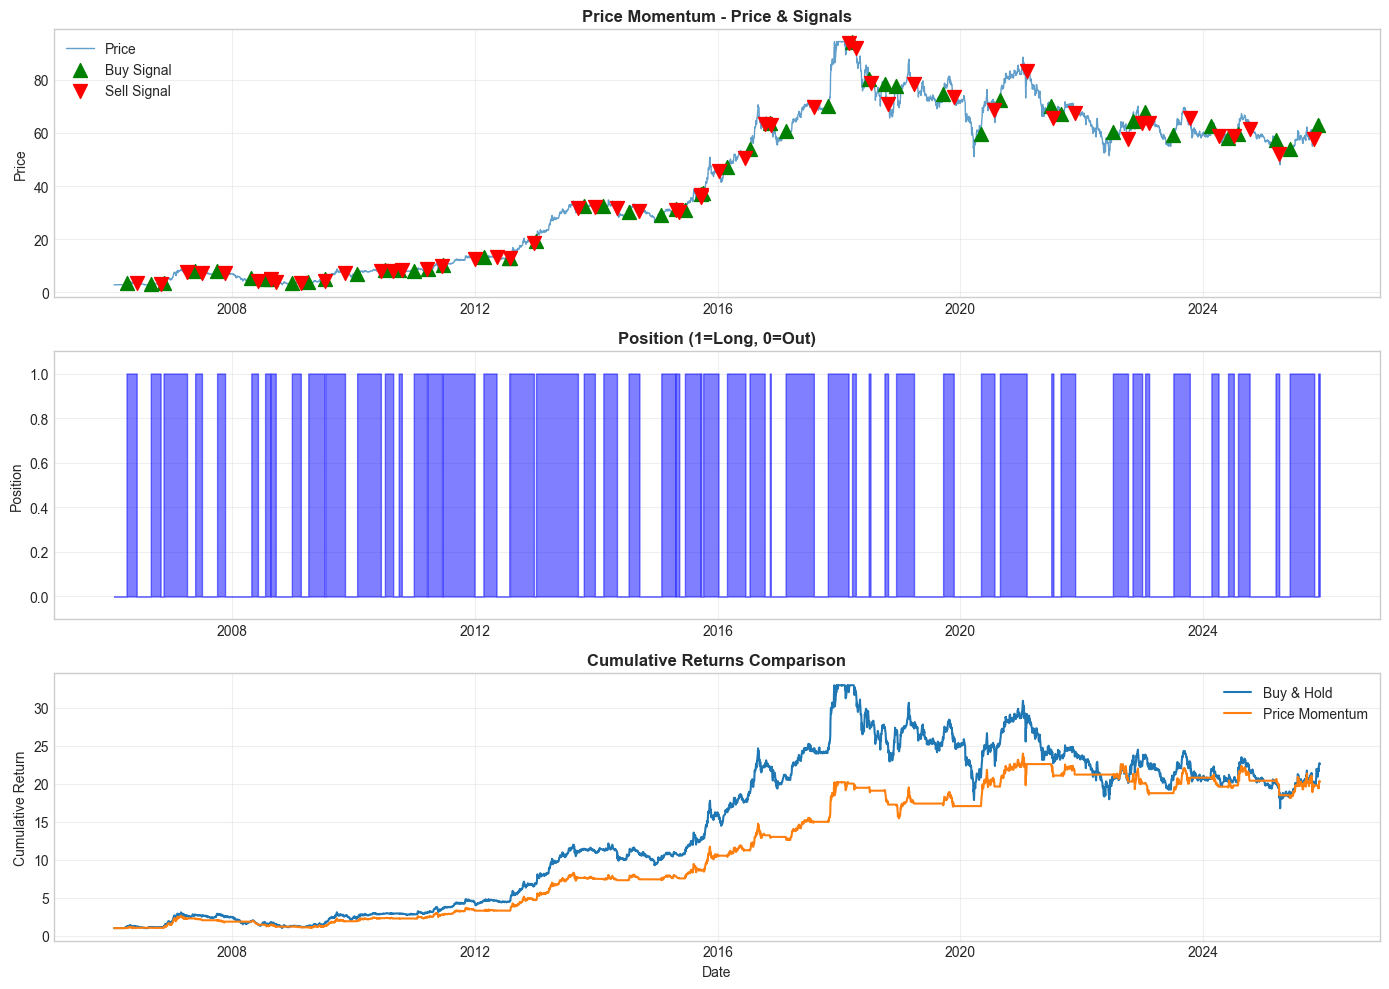

In [6]:
# ========== DEMO 1: PRICE MOMENTUM (MA CROSSOVER) ==========

strategy_1 = PriceMomentum(short_window=20, long_window=50)
result_1 = strategy_1.generate_signals(df)
backtest_1 = backtest_strategy(df, strategy_1)

print_backtest_results(backtest_1, "Price Momentum (SMA 20/50 Crossover)")
plot_strategy_analysis(df, result_1, backtest_1, "Price Momentum")

This strategy long when short-term moving average crosses above long-term moving average.

Result shows a steady upward trend, indicating that following the moving average crossover can be effective in capturing long-term trends. However, there are periods of drawdown during market corrections. 
Sharpe Ratio: 0.78 means the strategy provides a good risk-adjusted return, indicating that the returns are favorable compared to the volatility of the strategy. But max drawdown is -64% means the strategy can experience significant losses during downturns, which is a risk factor to consider.

## RSI Momentum - Relative Strength Index


RSI Momentum (14-period, 30/70)
Total Return:   111.99%
Annual Return:  3.90%
Sharpe Ratio:   0.20
Max Drawdown:   -51.92%
Win Rate:       46.49%
Num Trades:     55


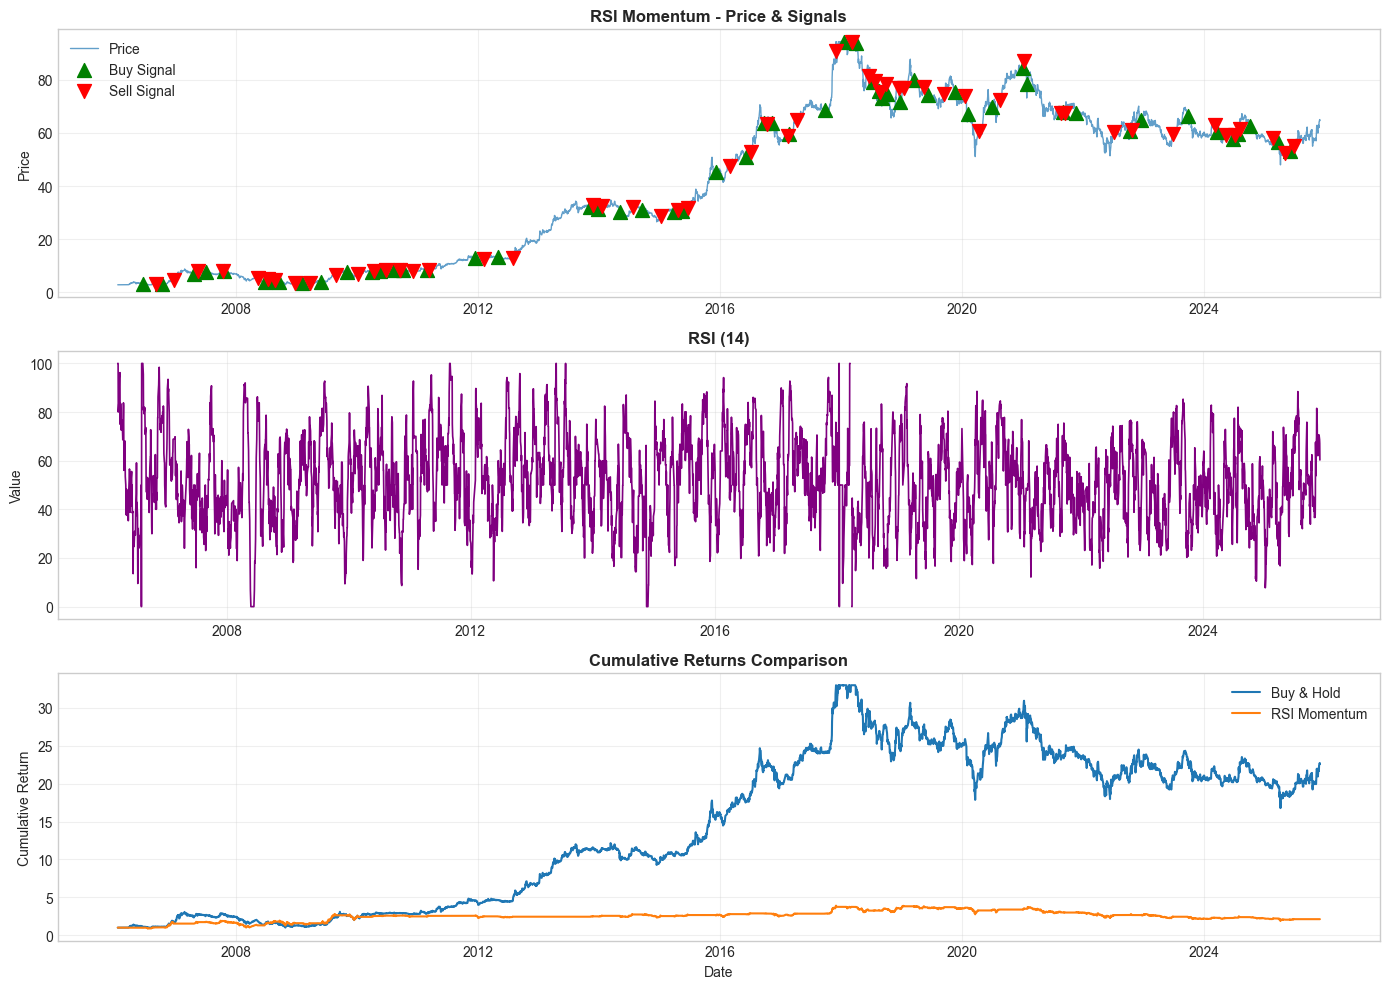

In [22]:
# ========== DEMO 2: RSI MOMENTUM ==========

strategy_2 = RSIMomentum(period=14, oversold=30, overbought=70)
result_2 = strategy_2.generate_signals(df)
backtest_2 = backtest_strategy(df, strategy_2)

print_backtest_results(backtest_2, "RSI Momentum (14-period, 30/70)")
plot_strategy_analysis(df, result_2, backtest_2, "RSI Momentum", indicator_col='rsi', indicator_name='RSI (14)')

As we can see, metrics show RSIMomentum strategy works worse than PriceMomentum strategy. But these methods significantly rely on parameter tuning to achieve optimal performance.
Let's find if we can optimize the parameters for better results.

## Optimize Parameters 

In [20]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    p = trial.suggest_int("period", 5, 30)
    os = trial.suggest_int("oversold", 10, 40)
    ob = trial.suggest_int("overbought", 60, 90)
    
    strategy = RSIMomentum(period=p, oversold=os, overbought=ob)
    result = strategy.calculate_returns(df)
    sharpe = result['strategy_return'].mean() / result['strategy_return'].std()
    
    return sharpe

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"Best params: {study.best_params}")

  0%|          | 0/200 [00:00<?, ?it/s]

Best params: {'period': 22, 'oversold': 17, 'overbought': 89}
Best Sharpe: 0.0555


Optimized Parameters: {'period': 22, 'oversold': 17, 'overbought': 89}


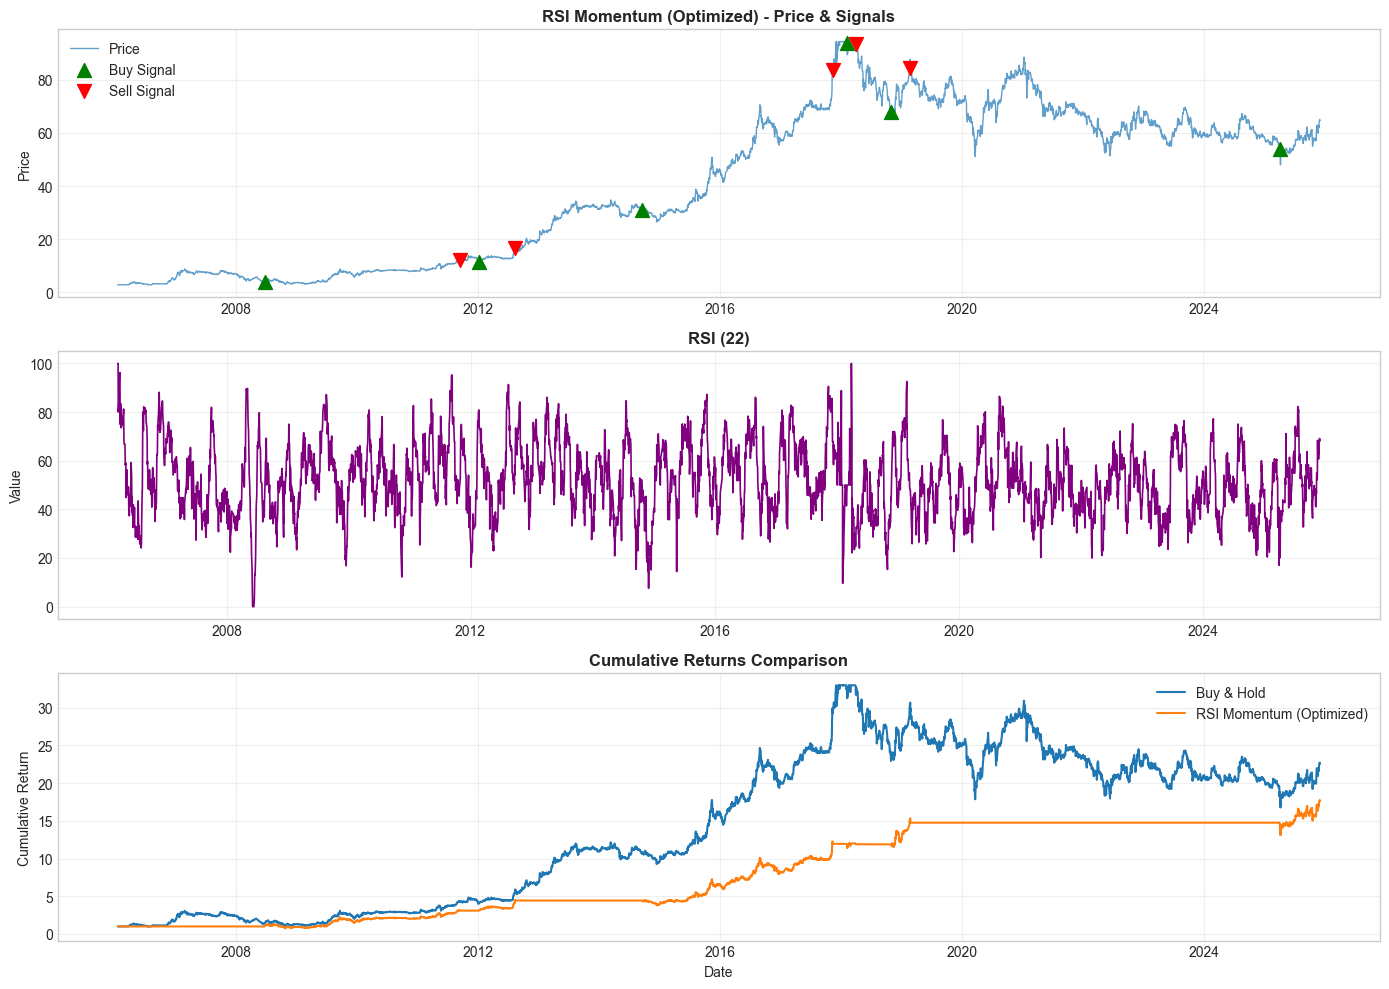


COMPARISON: Default vs Optimized RSI Momentum
Metric               Default (14, 30/70)       Optimized                
----------------------------------------------------------------------
Total Return         111.99%                   1664.41%                 
Annual Return        3.90%                     15.72%                   
Sharpe Ratio         0.20                      0.85                     
Max Drawdown         -51.92%                   -44.34%                  
Win Rate             46.49%                    51.16%                   
Num Trades           55                        5                        


In [24]:
# ========== RETRY RSI MOMENTUM WITH OPTIMIZED PARAMETERS ==========

best_params = study.best_params
print(f"Optimized Parameters: {best_params}")

strategy_2_opt = RSIMomentum(
    period=best_params['period'],
    oversold=best_params['oversold'],
    overbought=best_params['overbought']
)
result_2_opt = strategy_2_opt.generate_signals(df)
backtest_2_opt = backtest_strategy(df, strategy_2_opt)
plot_strategy_analysis(df, result_2_opt, backtest_2_opt, "RSI Momentum (Optimized)", indicator_col='rsi', indicator_name=f"RSI ({best_params['period']})")

# Compare default vs optimized
print("\n" + "="*60)
print("COMPARISON: Default vs Optimized RSI Momentum")
print("="*60)
print(f"{'Metric':<20} {'Default (14, 30/70)':<25} {'Optimized':<25}")
print("-"*70)
print(f"{'Total Return':<20} {backtest_2['total_return']:<25.2%} {backtest_2_opt['total_return']:<25.2%}")
print(f"{'Annual Return':<20} {backtest_2['annual_return']:<25.2%} {backtest_2_opt['annual_return']:<25.2%}")
print(f"{'Sharpe Ratio':<20} {backtest_2['sharpe_ratio']:<25.2f} {backtest_2_opt['sharpe_ratio']:<25.2f}")
print(f"{'Max Drawdown':<20} {backtest_2['max_drawdown']:<25.2%} {backtest_2_opt['max_drawdown']:<25.2%}")
print(f"{'Win Rate':<20} {backtest_2['win_rate']:<25.2%} {backtest_2_opt['win_rate']:<25.2%}")
print(f"{'Num Trades':<20} {int(backtest_2['num_trades']):<25} {int(backtest_2_opt['num_trades']):<25}")

RSIMomentum with optimized parameters shows significant improvement in performance and robustness than PriceMomentum. Max drawdown is reduced, indicating better risk management during market downturns. But trade frequency is lower, means holding periods are longer.

# Compare Strategies for single stock

In [28]:
# Find optimized parameters for each momentum strategy using Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optimize_strategy(strategy_name, param_space, n_trials=100):
    """
    Generic function to optimize strategy parameters.
    
    Args:
        strategy_name: Name of the strategy class
        param_space: Dictionary defining parameter search space
        n_trials: Number of optimization trials
    
    Returns:
        Best parameters and best Sharpe ratio
    """
    def objective(trial):
        params = {}
        for param_name, (param_type, *bounds) in param_space.items():
            if param_type == 'int':
                params[param_name] = trial.suggest_int(param_name, bounds[0], bounds[1])
            elif param_type == 'float':
                params[param_name] = trial.suggest_float(param_name, bounds[0], bounds[1])
        
        # Create strategy with suggested parameters
        strategy = eval(strategy_name)(**params)
        result = backtest_strategy(df, strategy)
        
        # Use Sharpe ratio as objective (can also use total_return)
        return result['sharpe_ratio']
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    return study.best_params, study.best_value

# Define parameter search spaces for each strategy
param_spaces = {
    'PriceMomentum': {
        'short_window': ('int', 5, 50),
        'long_window': ('int', 20, 200),
    },
    'ROCMomentum': {
        'period': ('int', 5, 60),
        'threshold': ('float', -5.0, 5.0),
    },
    'RSIMomentum': {
        'period': ('int', 5, 30),
        'oversold': ('int', 10, 40),
        'overbought': ('int', 60, 90),
    },
    'MACDMomentum': {
        'fast': ('int', 5, 20),
        'slow': ('int', 15, 40),
        'signal': ('int', 5, 15),
    },
    'VolumeWeightedMomentum': {
        'price_period': ('int', 5, 50),
        'volume_period': ('int', 5, 50),
        'volume_factor': ('float', 1.0, 3.0),
    },
    'OBVMomentum': {
        'obv_period': ('int', 5, 50),
    },
    'VPTMomentum': {
        'vpt_period': ('int', 5, 50),
    },
    'MFIMomentum': {
        'period': ('int', 5, 30),
        'oversold': ('int', 10, 30),
        'overbought': ('int', 70, 90),
    },
    'TripleMomentum': {
        'short': ('int', 5, 42),
        'medium': ('int', 21, 126),
        'long': ('int', 126, 504),
    },
    'AcceleratingMomentum': {
        'momentum_period': ('int', 5, 50),
        'acceleration_period': ('int', 3, 20),
    },
}

# Run optimization for each strategy
print(f"{'='*80}")
print(f"OPTIMIZING MOMENTUM STRATEGIES FOR {SYMBOL}")
print(f"{'='*80}\n")

optimized_results = {}

for strategy_name, param_space in param_spaces.items():
    print(f"Optimizing {strategy_name}...")
    best_params, best_sharpe = optimize_strategy(strategy_name, param_space, n_trials=100)
    optimized_results[strategy_name] = {
        'params': best_params,
        'sharpe': best_sharpe
    }
    print(f"  Best params: {best_params}")
    print(f"  Best Sharpe: {best_sharpe:.3f}\n")

# Create summary DataFrame
summary_data = []
for strategy_name, result in optimized_results.items():
    summary_data.append({
        'Strategy': strategy_name,
        'Optimized Sharpe': f"{result['sharpe']:.3f}",
        'Best Parameters': str(result['params'])
    })

optimized_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("OPTIMIZATION SUMMARY")
print("="*80)
display(optimized_df)

OPTIMIZING MOMENTUM STRATEGIES FOR VNM

Optimizing PriceMomentum...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best params: {'short_window': 8, 'long_window': 53}
  Best Sharpe: 0.904

Optimizing ROCMomentum...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best params: {'period': 37, 'threshold': 0.9144555836922788}
  Best Sharpe: 0.887

Optimizing RSIMomentum...


...

  0%|          | 0/100 [00:00<?, ?it/s]

  Best params: {'short': 35, 'medium': 119, 'long': 171}
  Best Sharpe: 0.832

Optimizing AcceleratingMomentum...


  0%|          | 0/100 [00:00<?, ?it/s]

  Best params: {'momentum_period': 14, 'acceleration_period': 6}
  Best Sharpe: 0.698


OPTIMIZATION SUMMARY


,Strategy,Optimized Sharpe,Best Parameters
0,PriceMomentum,0.904,"{'short_window': 8, 'long_window': 53}"
1,ROCMomentum,0.887,"{'period': 37, 'threshold': 0.9144555836922788}"
2,RSIMomentum,0.836,"{'period': 22, 'oversold': 18, 'overbought': 79}"
3,MACDMomentum,0.747,"{'fast': 10, 'slow': 40, 'signal': 15}"
4,VolumeWeightedMomentum,0.775,"{'price_period': 13, 'volume_period': 7, 'volu..."
5,OBVMomentum,0.719,{'obv_period': 22}
6,VPTMomentum,0.776,{'vpt_period': 21}
7,MFIMomentum,0.729,"{'period': 27, 'oversold': 21, 'overbought': 87}"
8,TripleMomentum,0.832,"{'short': 35, 'medium': 119, 'long': 171}"
9,AcceleratingMomentum,0.698,"{'momentum_period': 14, 'acceleration_period': 6}"



OPTIMIZED MOMENTUM STRATEGIES COMPARISON - VNM


,Strategy,Total Return,Annual Return,Volatility,Sharpe Ratio,Max Drawdown,Win Rate,Num Trades
0,Price Momentum,2883.30%,18.85%,20.85%,0.90,-41.20%,50.02%,58
1,ROC Momentum,2534.58%,18.11%,20.42%,0.89,-40.81%,47.00%,156
2,RSI Momentum,351.71%,7.97%,9.54%,0.84,-15.88%,53.10%,8
3,MACD Momentum,1369.63%,14.65%,19.62%,0.75,-45.09%,46.34%,140
4,Volume-Weighted Momentum,610.84%,10.49%,13.54%,0.77,-21.95%,28.53%,575
5,OBV Momentum,1369.65%,14.65%,20.38%,0.72,-41.32%,45.37%,238
6,VPT Momentum,1746.25%,15.99%,20.61%,0.78,-46.33%,45.98%,186
7,MFI Momentum,1815.70%,16.21%,22.24%,0.73,-44.34%,49.25%,1
8,Triple Momentum,1354.05%,14.59%,17.54%,0.83,-37.15%,47.89%,114
9,Accelerating Momentum,720.72%,11.30%,16.18%,0.70,-50.00%,37.32%,368


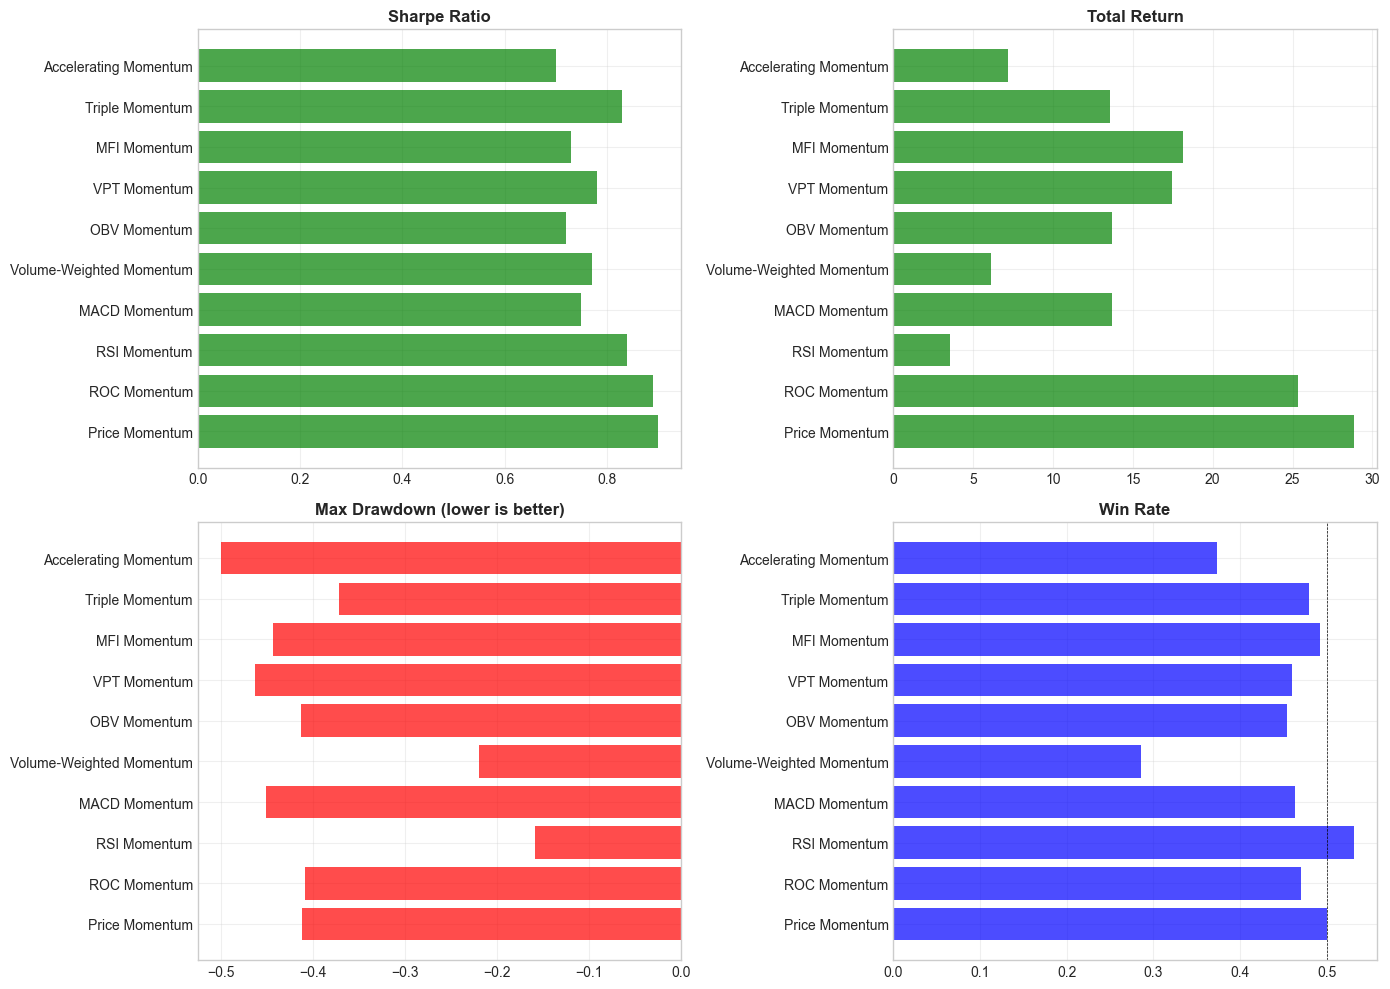

In [31]:
# ========== COMPARE OPTIMIZED MOMENTUM STRATEGIES ==========

# Create strategies with optimized parameters
optimized_strategies = [
    PriceMomentum(**optimized_results['PriceMomentum']['params']),
    ROCMomentum(**optimized_results['ROCMomentum']['params']),
    RSIMomentum(**optimized_results['RSIMomentum']['params']),
    MACDMomentum(**optimized_results['MACDMomentum']['params']),
    VolumeWeightedMomentum(**optimized_results['VolumeWeightedMomentum']['params']),
    OBVMomentum(**optimized_results['OBVMomentum']['params']),
    VPTMomentum(**optimized_results['VPTMomentum']['params']),
    MFIMomentum(**optimized_results['MFIMomentum']['params']),
    TripleMomentum(**optimized_results['TripleMomentum']['params']),
    AcceleratingMomentum(**optimized_results['AcceleratingMomentum']['params'])
]

optimized_comparison = compare_strategies(df, optimized_strategies)

print(f"\n{'='*100}")
print(f"OPTIMIZED MOMENTUM STRATEGIES COMPARISON - {SYMBOL}")
print("="*100)
display(optimized_comparison)

plot_comparison_charts(optimized_comparison)

# Compare Strategies Across Multiple Stocks

Goal: Find the **best strategies** that perform consistently well across different stocks.

**Approach: Universal Optimization** - Optimize parameters across ALL stocks simultaneously to find robust parameters that work well on average.

In [38]:
# ========== UNIVERSAL OPTIMIZATION: FIND BEST PARAMS ACROSS ALL STOCKS ==========

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optimize_strategy_universal(strategy_name, param_space, all_data, n_trials=100):
    """
    Optimize strategy parameters across ALL stocks simultaneously.
    Objective: Maximize AVERAGE Sharpe ratio across all stocks.
    
    This produces robust parameters that work well across different market conditions.
    """
    def objective(trial):
        # Sample parameters
        params = {}
        for param_name, (param_type, *bounds) in param_space.items():
            if param_type == 'int':
                params[param_name] = trial.suggest_int(param_name, bounds[0], bounds[1])
            elif param_type == 'float':
                params[param_name] = trial.suggest_float(param_name, bounds[0], bounds[1])
        
        # Create strategy and test on ALL stocks
        strategy = eval(strategy_name)(**params)
        
        sharpe_ratios = []
        for symbol, data in all_data.items():
            try:
                result = backtest_strategy(data, strategy)
                sharpe_ratios.append(result['sharpe_ratio'])
            except:
                sharpe_ratios.append(-10)  # Penalty for failed backtest
        
        # Return AVERAGE Sharpe across all stocks
        valid_sharpes = [s for s in sharpe_ratios if s > -10]
        if len(valid_sharpes) == 0:
            return -10
        
        # Can also add penalty for high variance to prefer consistent strategies
        avg_sharpe = np.mean(valid_sharpes)
        std_sharpe = np.std(valid_sharpes)
        
        # Objective: high average, low variance (penalize inconsistency)
        return avg_sharpe - 0.1 * std_sharpe
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    
    return study.best_params, study.best_value

# Define parameter search spaces
param_spaces = {
    'PriceMomentum': {
        'short_window': ('int', 5, 50),
        'long_window': ('int', 20, 200),
    },
    'ROCMomentum': {
        'period': ('int', 5, 60),
        'threshold': ('float', -5.0, 5.0),
    },
    'RSIMomentum': {
        'period': ('int', 5, 30),
        'oversold': ('int', 10, 40),
        'overbought': ('int', 60, 90),
    },
    'MACDMomentum': {
        'fast': ('int', 5, 20),
        'slow': ('int', 15, 40),
        'signal': ('int', 5, 15),
    },
    'VolumeWeightedMomentum': {
        'price_period': ('int', 5, 50),
        'volume_period': ('int', 5, 50),
        'volume_factor': ('float', 1.0, 3.0),
    },
    'OBVMomentum': {
        'obv_period': ('int', 5, 50),
    },
    'VPTMomentum': {
        'vpt_period': ('int', 5, 50),
    },
    'MFIMomentum': {
        'period': ('int', 5, 30),
        'oversold': ('int', 10, 30),
        'overbought': ('int', 70, 90),
    },
    'TripleMomentum': {
        'short': ('int', 5, 42),
        'medium': ('int', 21, 126),
        'long': ('int', 126, 504),
    },
    'AcceleratingMomentum': {
        'momentum_period': ('int', 5, 50),
        'acceleration_period': ('int', 3, 20),
    },
}

# Run UNIVERSAL optimization for each strategy
print("="*80)
print("UNIVERSAL OPTIMIZATION (Across ALL Stocks)")
print("="*80)
print(f"Stocks: {list(all_data.keys())}")
print(f"Objective: Maximize Average Sharpe - 0.1 × Std(Sharpe)")
print("="*80 + "\n")

universal_results = {}

for strategy_name, param_space in param_spaces.items():
    print(f"Optimizing {strategy_name}...")
    best_params, best_score = optimize_strategy_universal(
        strategy_name, param_space, all_data, n_trials=100
    )
    universal_results[strategy_name] = {
        'params': best_params,
        'score': best_score
    }
    print(f"  Universal params: {best_params}")
    print(f"  Optimization score: {best_score:.3f}\n")

# Summary
print("\n" + "="*80)
print("UNIVERSAL OPTIMIZATION SUMMARY")
print("="*80)
universal_df = pd.DataFrame([
    {'Strategy': name, 'Score': f"{r['score']:.3f}", 'Universal Parameters': str(r['params'])}
    for name, r in universal_results.items()
]).sort_values('Score', ascending=False)
display(universal_df)

UNIVERSAL OPTIMIZATION (Across ALL Stocks)
Stocks: ['ACB', 'BID', 'HPG', 'MSN', 'MWG', 'VCB', 'VHM', 'VIC', 'VNM', 'VPB']
Objective: Maximize Average Sharpe - 0.1 × Std(Sharpe)

Optimizing PriceMomentum...


  0%|          | 0/100 [00:00<?, ?it/s]

  Universal params: {'short_window': 5, 'long_window': 53}
  Optimization score: 0.613

Optimizing ROCMomentum...


  0%|          | 0/100 [00:00<?, ?it/s]

  Universal params: {'period': 34, 'threshold': 0.38978566354450966}
  Optimization score: 0.638

Optimizing RSIMomentum...


...

  0%|          | 0/100 [00:00<?, ?it/s]

  Universal params: {'short': 35, 'medium': 37, 'long': 200}
  Optimization score: 0.591

Optimizing AcceleratingMomentum...


  0%|          | 0/100 [00:00<?, ?it/s]

  Universal params: {'momentum_period': 36, 'acceleration_period': 19}
  Optimization score: 0.618


UNIVERSAL OPTIMIZATION SUMMARY


,Strategy,Score,Universal Parameters
3,MACDMomentum,0.653,"{'fast': 11, 'slow': 39, 'signal': 15}"
1,ROCMomentum,0.638,"{'period': 34, 'threshold': 0.38978566354450966}"
9,AcceleratingMomentum,0.618,"{'momentum_period': 36, 'acceleration_period':..."
0,PriceMomentum,0.613,"{'short_window': 5, 'long_window': 53}"
8,TripleMomentum,0.591,"{'short': 35, 'medium': 37, 'long': 200}"
6,VPTMomentum,0.560,{'vpt_period': 29}
5,OBVMomentum,0.552,{'obv_period': 22}
4,VolumeWeightedMomentum,0.521,"{'price_period': 5, 'volume_period': 18, 'volu..."
7,MFIMomentum,0.456,"{'period': 27, 'oversold': 19, 'overbought': 88}"
2,RSIMomentum,0.434,"{'period': 30, 'oversold': 30, 'overbought': 90}"


In [39]:
# ========== BACKTEST UNIVERSAL PARAMETERS ON ALL STOCKS ==========

# Create strategy configurations from universal optimization results
strategy_configs = {name: result['params'] for name, result in universal_results.items()}

# Backtest all strategies on all stocks
all_results = []

for symbol, data in all_data.items():
    for strategy_name, params in strategy_configs.items():
        try:
            strategy = eval(strategy_name)(**params)
            result = backtest_strategy(data, strategy)
            all_results.append({
                'Symbol': symbol,
                'Strategy': strategy_name,
                'Sharpe Ratio': result['sharpe_ratio'],
                'Total Return': result['total_return'],
                'Max Drawdown': result['max_drawdown'],
                'Win Rate': result['win_rate'],
                'Num Trades': result['num_trades']
            })
        except Exception as e:
            print(f"Error: {symbol} - {strategy_name}: {e}")
            all_results.append({
                'Symbol': symbol,
                'Strategy': strategy_name,
                'Sharpe Ratio': np.nan,
                'Total Return': np.nan,
                'Max Drawdown': np.nan,
                'Win Rate': np.nan,
                'Num Trades': 0
            })

results_df = pd.DataFrame(all_results)
print(f"Total backtests: {len(results_df)} ({len(strategy_configs)} strategies × {len(all_data)} stocks)")
display(results_df.head(20))

Total backtests: 100 (10 strategies × 10 stocks)


,Symbol,Strategy,Sharpe Ratio,Total Return,Max Drawdown,Win Rate,Num Trades
0,ACB,PriceMomentum,0.556607,8.841268,-0.384747,0.487310,76.0
1,ACB,ROCMomentum,0.581239,9.664428,-0.514439,0.460945,168.0
2,ACB,RSIMomentum,0.247015,2.683449,-0.736301,0.492330,3.5
3,ACB,MACDMomentum,0.617166,9.421199,-0.477425,0.461502,134.0
4,ACB,VolumeWeightedMomentum,0.330889,1.446710,-0.369742,0.283898,446.5
5,ACB,OBVMomentum,0.267218,2.099034,-0.584031,0.432771,265.0
6,ACB,VPTMomentum,0.438243,5.515944,-0.556882,0.458929,157.0
7,ACB,MFIMomentum,0.219986,1.104986,-0.636792,0.500933,3.5
8,ACB,TripleMomentum,0.500712,4.420080,-0.385588,0.474510,104.0
9,ACB,AcceleratingMomentum,0.740138,9.900280,-0.403274,0.432381,203.0


In [40]:
# ========== STRATEGY PERFORMANCE SUMMARY ==========

# Aggregate metrics by strategy (average across all stocks)
strategy_summary = results_df.groupby('Strategy').agg({
    'Sharpe Ratio': ['mean', 'std', 'min', 'max'],
    'Total Return': ['mean', 'std'],
    'Max Drawdown': ['mean', 'min'],  # min is worst drawdown
    'Win Rate': 'mean',
    'Symbol': 'count'
}).round(3)

strategy_summary.columns = ['Sharpe_Mean', 'Sharpe_Std', 'Sharpe_Min', 'Sharpe_Max',
                            'Return_Mean', 'Return_Std', 'MaxDD_Mean', 'MaxDD_Worst', 
                            'WinRate_Mean', 'Num_Stocks']

# Calculate consistency score (high mean, low std = more consistent)
strategy_summary['Consistency'] = strategy_summary['Sharpe_Mean'] / (strategy_summary['Sharpe_Std'] + 0.1)

# Sort by Sharpe Mean
strategy_summary = strategy_summary.sort_values('Sharpe_Mean', ascending=False)

print("\n" + "="*100)
print("STRATEGY PERFORMANCE SUMMARY (Averaged Across All Stocks)")
print("="*100)
display(strategy_summary)

# Best strategies ranking
print("\n🏆 TOP 3 STRATEGIES BY AVERAGE SHARPE RATIO:")
for i, (strategy, row) in enumerate(strategy_summary.head(3).iterrows(), 1):
    print(f"  {i}. {strategy}")
    print(f"     Sharpe: {row['Sharpe_Mean']:.3f} (±{row['Sharpe_Std']:.3f})")
    print(f"     Return: {row['Return_Mean']:.2%} | MaxDD: {row['MaxDD_Mean']:.2%}")
    print(f"     Parameters: {strategy_configs[strategy]}")
    print()


STRATEGY PERFORMANCE SUMMARY (Averaged Across All Stocks)


,Sharpe_Mean,Sharpe_Std,Sharpe_Min,Sharpe_Max,Return_Mean,Return_Std,MaxDD_Mean,MaxDD_Worst,WinRate_Mean,Num_Stocks,Consistency
Strategy,,,,,,,,,,,
MACDMomentum,0.678,0.267,0.184,1.019,10.991,13.403,-0.419,-0.660,0.473,10,1.847411
ROCMomentum,0.660,0.232,0.291,0.942,10.288,11.237,-0.463,-0.631,0.473,10,1.987952
AcceleratingMomentum,0.649,0.325,0.122,1.033,6.510,6.624,-0.386,-0.661,0.442,10,1.527059
PriceMomentum,0.636,0.250,0.210,0.998,12.309,14.338,-0.450,-0.663,0.495,10,1.817143
TripleMomentum,0.614,0.239,0.270,0.953,6.644,7.343,-0.387,-0.499,0.478,10,1.811209
OBVMomentum,0.583,0.328,0.179,1.002,12.281,17.565,-0.485,-0.612,0.455,10,1.362150
VPTMomentum,0.581,0.218,0.221,0.862,8.354,9.329,-0.486,-0.610,0.472,10,1.827044
VolumeWeightedMomentum,0.544,0.245,0.053,0.984,2.166,1.518,-0.295,-0.469,0.297,10,1.576812
MFIMomentum,0.471,0.160,0.192,0.661,9.361,11.518,-0.530,-0.696,0.505,10,1.811538



🏆 TOP 3 STRATEGIES BY AVERAGE SHARPE RATIO:
  1. MACDMomentum
     Sharpe: 0.678 (±0.267)
     Return: 1099.10% | MaxDD: -41.90%
     Parameters: {'fast': 11, 'slow': 39, 'signal': 15}

  2. ROCMomentum
     Sharpe: 0.660 (±0.232)
     Return: 1028.80% | MaxDD: -46.30%
     Parameters: {'period': 34, 'threshold': 0.38978566354450966}

  3. AcceleratingMomentum
     Sharpe: 0.649 (±0.325)
     Return: 651.00% | MaxDD: -38.60%
     Parameters: {'momentum_period': 36, 'acceleration_period': 19}



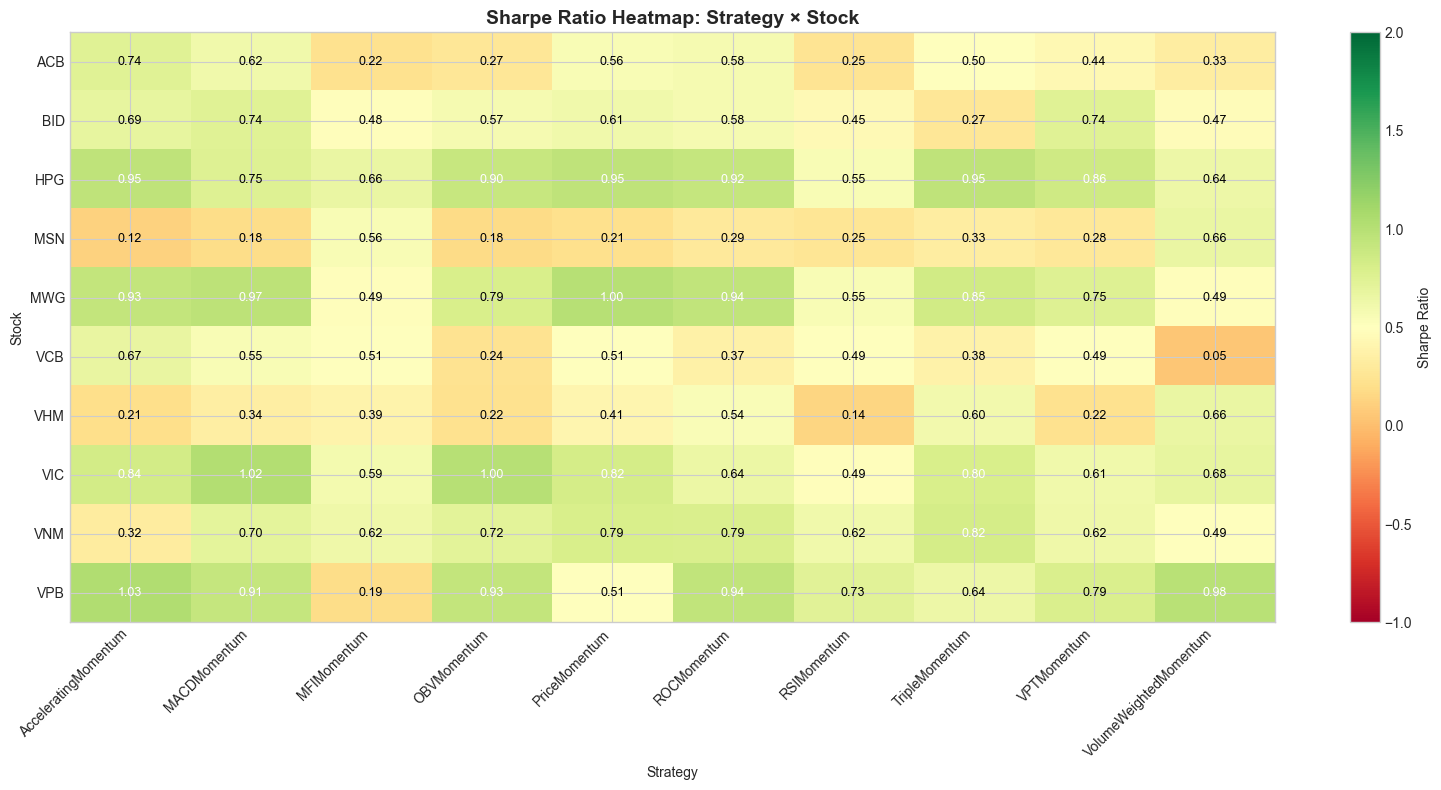


📊 BEST STRATEGY FOR EACH STOCK:
  ACB: AcceleratingMomentum (Sharpe=0.74)
  BID: MACDMomentum (Sharpe=0.74)
  HPG: TripleMomentum (Sharpe=0.95)
  MSN: VolumeWeightedMomentum (Sharpe=0.66)
  MWG: PriceMomentum (Sharpe=1.00)
  VCB: AcceleratingMomentum (Sharpe=0.67)
  VHM: VolumeWeightedMomentum (Sharpe=0.66)
  VIC: MACDMomentum (Sharpe=1.02)
  VNM: TripleMomentum (Sharpe=0.82)
  VPB: AcceleratingMomentum (Sharpe=1.03)


In [41]:
# ========== SHARPE RATIO HEATMAP: STRATEGY × STOCK ==========

# Create pivot table
pivot_sharpe = results_df.pivot(index='Symbol', columns='Strategy', values='Sharpe Ratio')

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(pivot_sharpe.values, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=2)

# Add labels
ax.set_xticks(np.arange(len(pivot_sharpe.columns)))
ax.set_yticks(np.arange(len(pivot_sharpe.index)))
ax.set_xticklabels(pivot_sharpe.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(pivot_sharpe.index, fontsize=10)

# Add values in cells
for i in range(len(pivot_sharpe.index)):
    for j in range(len(pivot_sharpe.columns)):
        val = pivot_sharpe.values[i, j]
        color = 'white' if abs(val) > 0.8 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, ax=ax, label='Sharpe Ratio')
ax.set_title('Sharpe Ratio Heatmap: Strategy × Stock', fontsize=14, fontweight='bold')
ax.set_xlabel('Strategy')
ax.set_ylabel('Stock')
plt.tight_layout()
plt.show()

# Find best strategy for each stock
best_per_stock = pivot_sharpe.idxmax(axis=1)
print("\n📊 BEST STRATEGY FOR EACH STOCK:")
for symbol, strategy in best_per_stock.items():
    sharpe = pivot_sharpe.loc[symbol, strategy]
    print(f"  {symbol}: {strategy} (Sharpe={sharpe:.2f})")

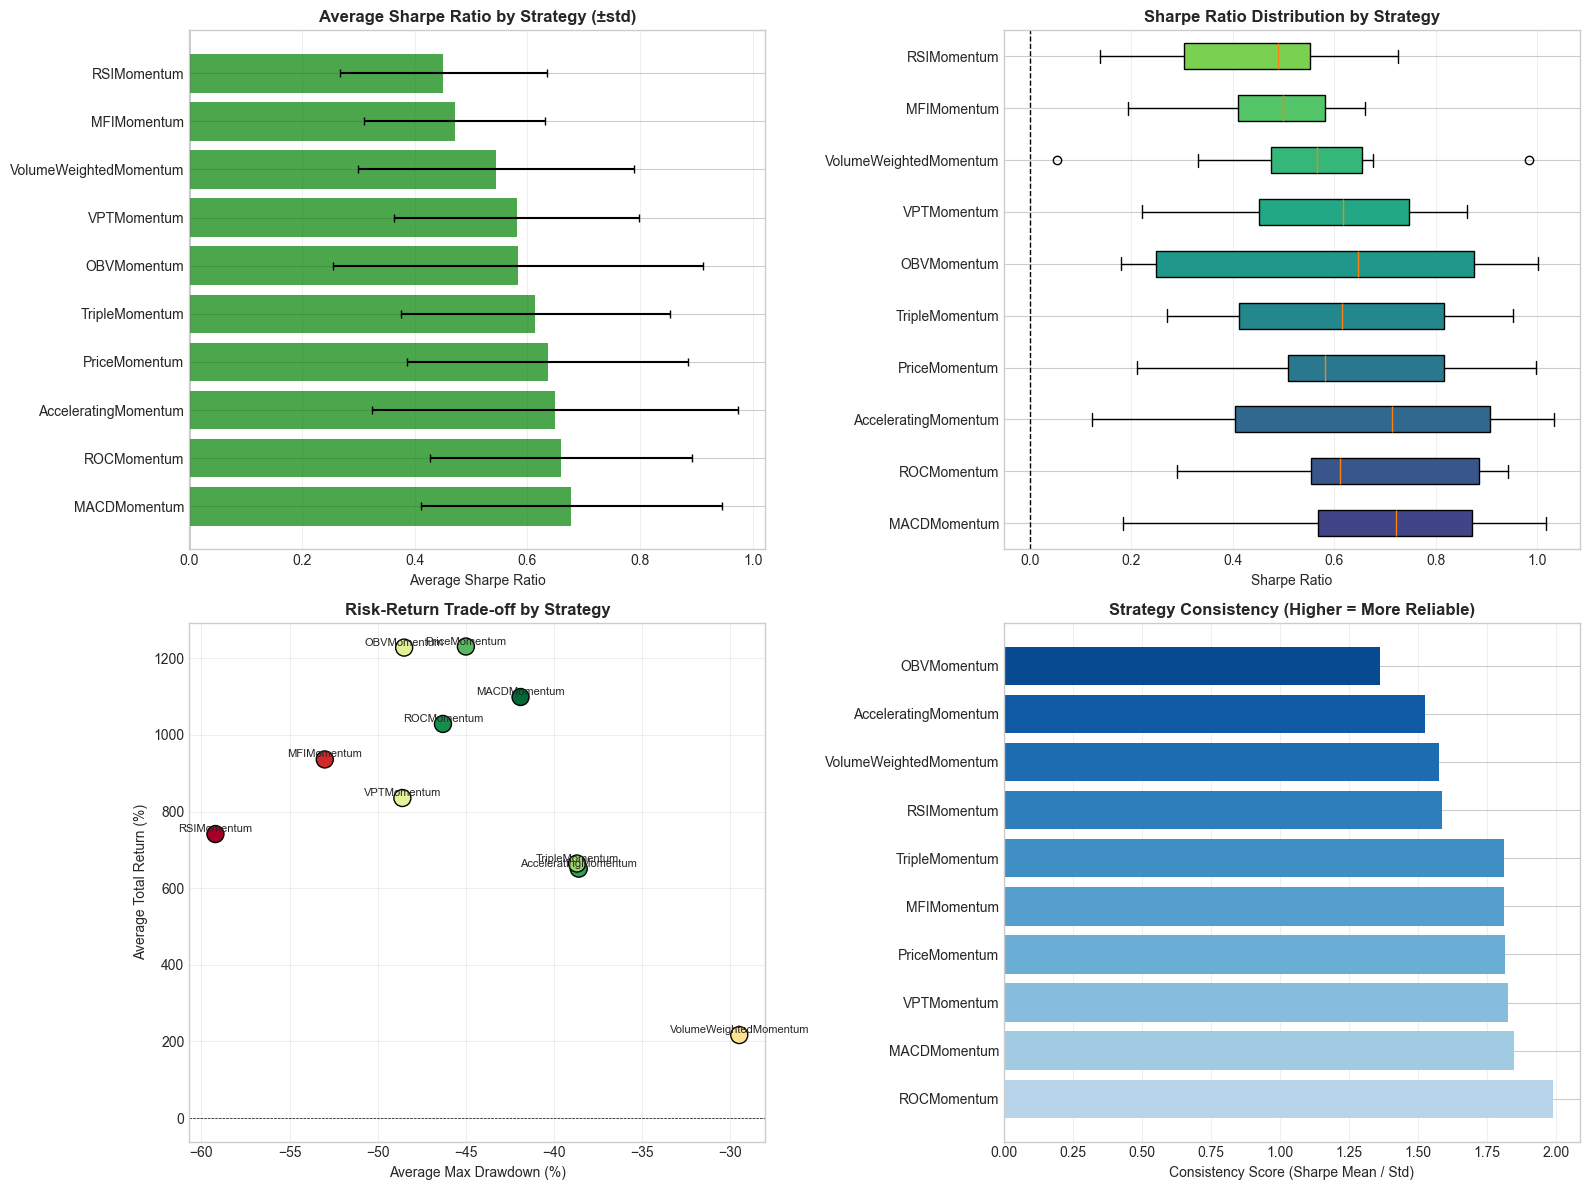

In [42]:
# ========== STRATEGY COMPARISON VISUALIZATION ==========

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average Sharpe Ratio by Strategy (with error bars)
ax1 = axes[0, 0]
strategies = strategy_summary.index.tolist()
sharpe_means = strategy_summary['Sharpe_Mean'].values
sharpe_stds = strategy_summary['Sharpe_Std'].values
colors = ['green' if x > 0 else 'red' for x in sharpe_means]

bars = ax1.barh(strategies, sharpe_means, xerr=sharpe_stds, color=colors, alpha=0.7, capsize=3)
ax1.axvline(x=0, color='black', linewidth=1)
ax1.set_xlabel('Average Sharpe Ratio')
ax1.set_title('Average Sharpe Ratio by Strategy (±std)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 2. Strategy Performance Across Stocks (Box Plot)
ax2 = axes[0, 1]
strategy_order = strategy_summary.index.tolist()
boxplot_data = [results_df[results_df['Strategy'] == s]['Sharpe Ratio'].values for s in strategy_order]
bp = ax2.boxplot(boxplot_data, labels=strategy_order, vert=False, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.viridis(np.linspace(0.2, 0.8, len(strategy_order)))):
    patch.set_facecolor(color)
ax2.axvline(x=0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('Sharpe Ratio')
ax2.set_title('Sharpe Ratio Distribution by Strategy', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# 3. Average Return vs Max Drawdown (Risk-Return Trade-off)
ax3 = axes[1, 0]
returns = strategy_summary['Return_Mean'].values * 100
drawdowns = strategy_summary['MaxDD_Mean'].values * 100
ax3.scatter(drawdowns, returns, s=150, c=sharpe_means, cmap='RdYlGn', edgecolors='black', linewidth=1)
for i, strategy in enumerate(strategies):
    ax3.annotate(strategy, (drawdowns[i], returns[i]), fontsize=8, ha='center', va='bottom')
ax3.set_xlabel('Average Max Drawdown (%)')
ax3.set_ylabel('Average Total Return (%)')
ax3.set_title('Risk-Return Trade-off by Strategy', fontsize=12, fontweight='bold')
ax3.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax3.grid(True, alpha=0.3)

# 4. Consistency Score (Sharpe Mean / Sharpe Std)
ax4 = axes[1, 1]
consistency = strategy_summary['Consistency'].values
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(strategies)))
sorted_idx = np.argsort(consistency)[::-1]
ax4.barh([strategies[i] for i in sorted_idx], [consistency[i] for i in sorted_idx], color=colors)
ax4.set_xlabel('Consistency Score (Sharpe Mean / Std)')
ax4.set_title('Strategy Consistency (Higher = More Reliable)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

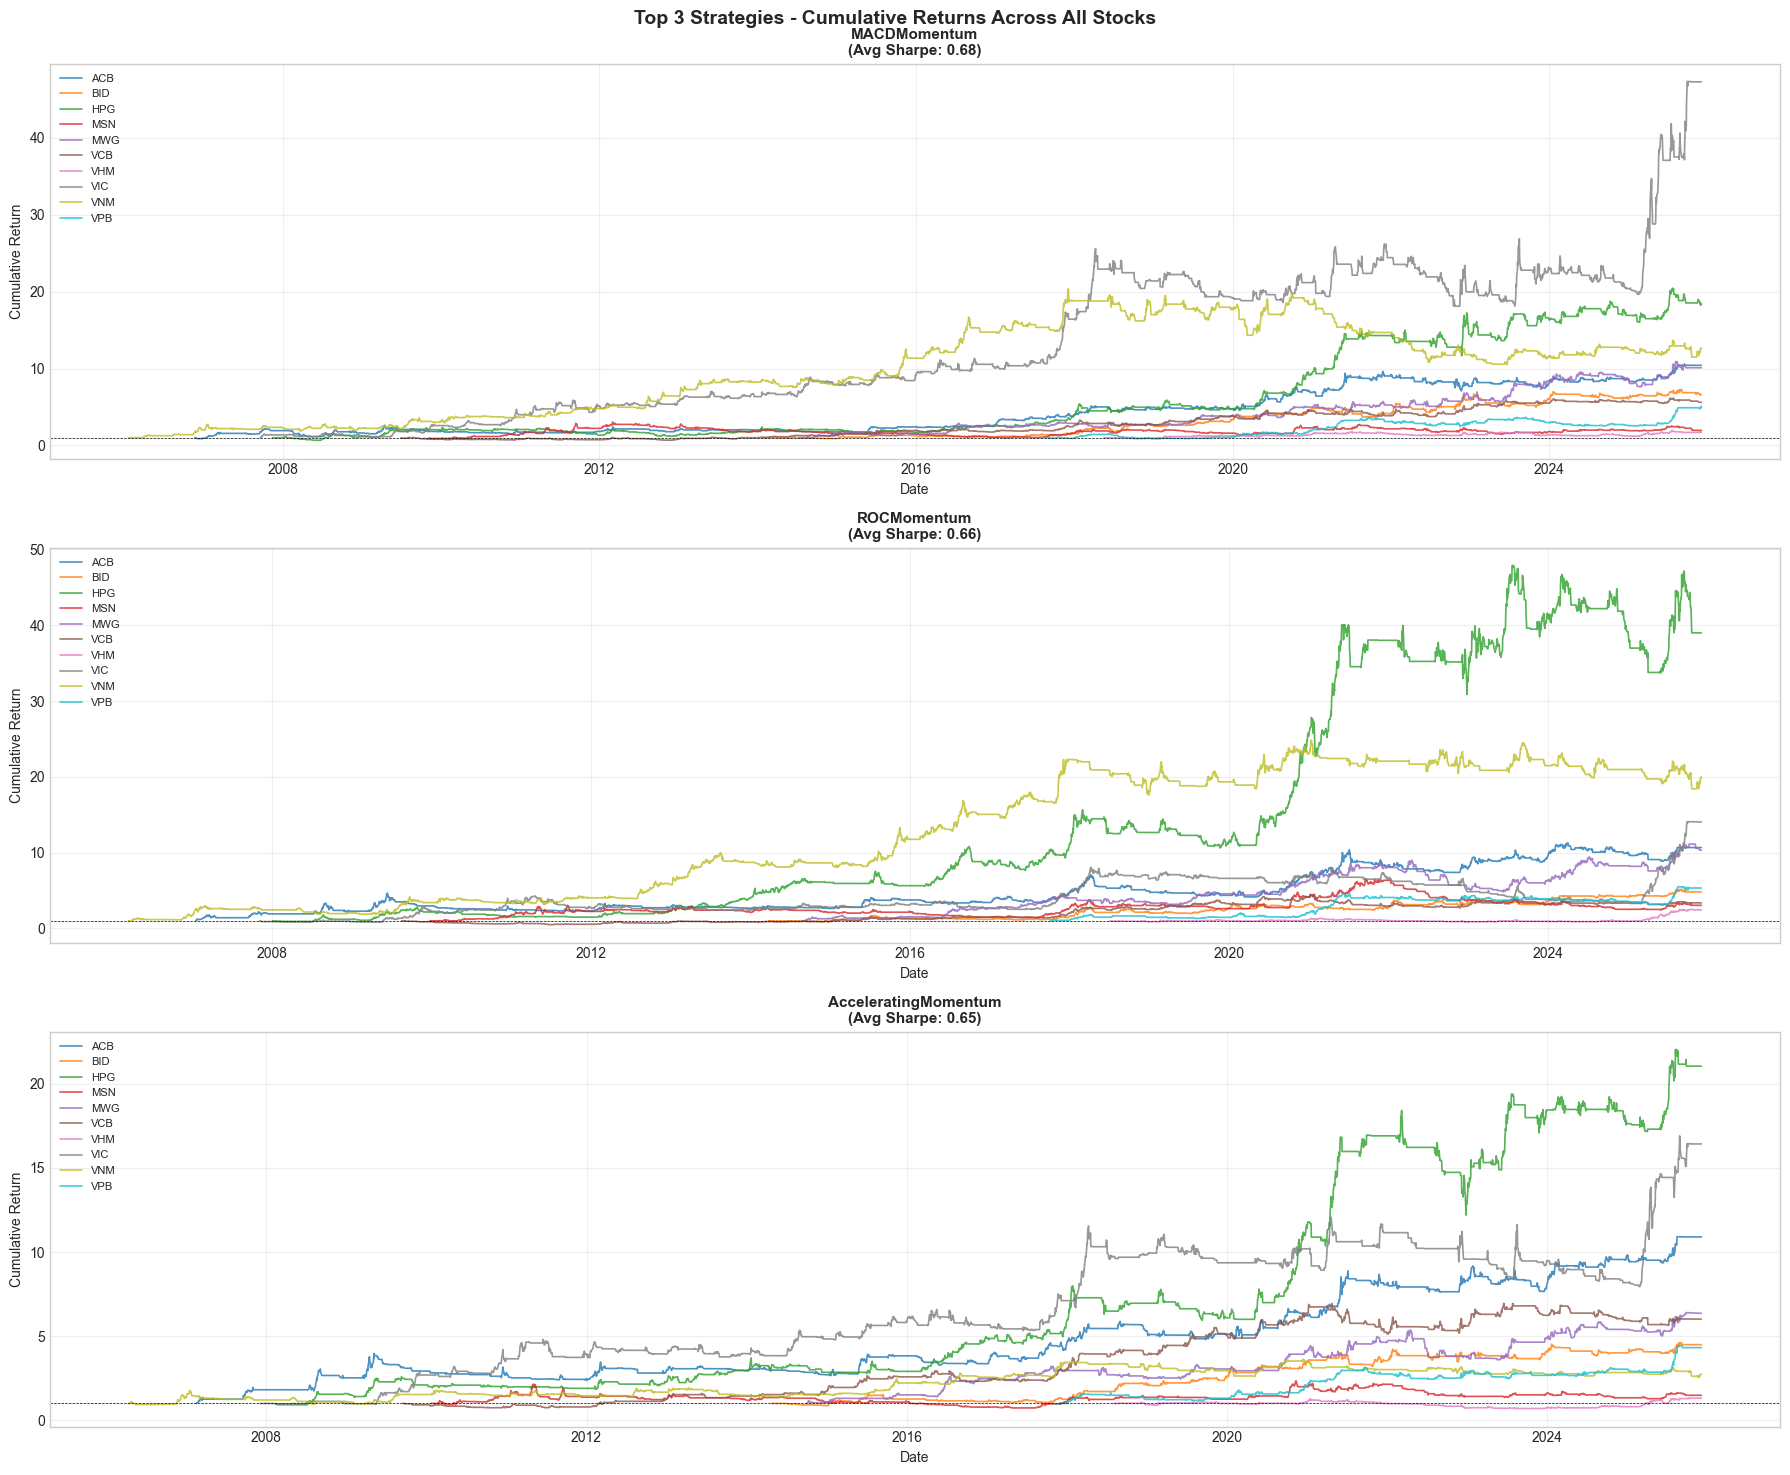

In [46]:
# ========== CUMULATIVE RETURNS: TOP 3 STRATEGIES ACROSS ALL STOCKS ==========

# Get top 3 strategies
top_3_strategies = strategy_summary.head(3).index.tolist()

fig, axes = plt.subplots(3, 1, figsize=(18, 15))

for idx, strategy_name in enumerate(top_3_strategies):
    ax = axes[idx]
    params = strategy_configs[strategy_name]
    strategy = eval(strategy_name)(**params)
    
    for symbol, data in all_data.items():
        try:
            result = backtest_strategy(data, strategy)
            result_data = result['data'].dropna()
            ax.plot(result_data['date'], result_data['cumulative_strategy_net'], 
                   label=symbol, linewidth=1.2, alpha=0.8)
        except:
            pass
    
    ax.set_title(f'{strategy_name}\n(Avg Sharpe: {strategy_summary.loc[strategy_name, "Sharpe_Mean"]:.2f})', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1, color='black', linestyle='--', linewidth=0.5)

plt.suptitle('Top 3 Strategies - Cumulative Returns Across All Stocks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [44]:
# ========== FINAL RECOMMENDATIONS ==========

print("\n" + "="*80)
print("📋 FINAL RECOMMENDATIONS")
print("="*80)

# Best overall strategy
best_overall = strategy_summary.index[0]
print(f"\n🥇 BEST OVERALL STRATEGY: {best_overall}")
print(f"   Parameters: {strategy_configs[best_overall]}")
print(f"   Avg Sharpe: {strategy_summary.loc[best_overall, 'Sharpe_Mean']:.3f}")
print(f"   Avg Return: {strategy_summary.loc[best_overall, 'Return_Mean']:.2%}")
print(f"   Avg MaxDD:  {strategy_summary.loc[best_overall, 'MaxDD_Mean']:.2%}")

# Most consistent strategy
most_consistent = strategy_summary['Consistency'].idxmax()
print(f"\n🎯 MOST CONSISTENT STRATEGY: {most_consistent}")
print(f"   Parameters: {strategy_configs[most_consistent]}")
print(f"   Consistency Score: {strategy_summary.loc[most_consistent, 'Consistency']:.2f}")

# Strategy with best worst-case (highest minimum Sharpe)
best_worst_case = strategy_summary['Sharpe_Min'].idxmax()
print(f"\n🛡️ BEST WORST-CASE STRATEGY: {best_worst_case}")
print(f"   Parameters: {strategy_configs[best_worst_case]}")
print(f"   Minimum Sharpe across all stocks: {strategy_summary.loc[best_worst_case, 'Sharpe_Min']:.3f}")

# Summary table
print("\n" + "-"*80)
print("RECOMMENDED STRATEGIES SUMMARY:")
print("-"*80)
recommendations = pd.DataFrame({
    'Strategy': [best_overall, most_consistent, best_worst_case],
    'Category': ['Best Average Performance', 'Most Consistent', 'Best Worst-Case'],
    'Avg Sharpe': [strategy_summary.loc[s, 'Sharpe_Mean'] for s in [best_overall, most_consistent, best_worst_case]],
    'Sharpe Std': [strategy_summary.loc[s, 'Sharpe_Std'] for s in [best_overall, most_consistent, best_worst_case]],
    'Avg Return': [f"{strategy_summary.loc[s, 'Return_Mean']:.2%}" for s in [best_overall, most_consistent, best_worst_case]],
})
display(recommendations)


📋 FINAL RECOMMENDATIONS

🥇 BEST OVERALL STRATEGY: MACDMomentum
   Parameters: {'fast': 11, 'slow': 39, 'signal': 15}
   Avg Sharpe: 0.678
   Avg Return: 1099.10%
   Avg MaxDD:  -41.90%

🎯 MOST CONSISTENT STRATEGY: ROCMomentum
   Parameters: {'period': 34, 'threshold': 0.38978566354450966}
   Consistency Score: 1.99

🛡️ BEST WORST-CASE STRATEGY: ROCMomentum
   Parameters: {'period': 34, 'threshold': 0.38978566354450966}
   Minimum Sharpe across all stocks: 0.291

--------------------------------------------------------------------------------
RECOMMENDED STRATEGIES SUMMARY:
--------------------------------------------------------------------------------


,Strategy,Category,Avg Sharpe,Sharpe Std,Avg Return
0,MACDMomentum,Best Average Performance,0.678,0.267,1099.10%
1,ROCMomentum,Most Consistent,0.660,0.232,1028.80%
2,ROCMomentum,Best Worst-Case,0.660,0.232,1028.80%


# Cross-sectional Momentum Porfolio

Now we have identified the best momentum strategies that perform well across multiple stocks. But we can not invest in all stocks equally because of capital constraints and risk management considerations. So we will build a cross-sectional portfolio that allocates capital to stocks. In this example, we use Momentum Score (12-month return) to rank stocks and allocate weights accordingly.

In [47]:
# Create momentum portfolio
from strategies.momentum import MomentumPortfolio

portfolio = MomentumPortfolio(lookback=252, holding_period=21, top_n=3)

# Get latest common date
latest_dates = [data['date'].max() for data in all_data.values()]
latest_date = min(latest_dates)

print(f"CROSS-SECTIONAL MOMENTUM PORTFOLIO")
print("="*60)
print(f"Construction Date: {latest_date}")
print(f"Lookback: 252 days (12 months)")
print(f"Holding Period: 21 days")
print(f"Top N: 3 stocks")
print("-"*60)

# Calculate momentum scores
scores = portfolio.calculate_momentum_scores(all_data, latest_date)

print("\n12-Month Momentum Scores (Return):")
print("-"*40)
for symbol, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {symbol}: {score:>8.2%} ")

# Get portfolio weights
weights = portfolio.get_portfolio_weights(all_data, latest_date)

print(f"\nRecommended Portfolio (Top 3 Momentum):")
print("-"*40)
for symbol, weight in weights.items():
    print(f"  {symbol}: {weight:.1%}")

CROSS-SECTIONAL MOMENTUM PORTFOLIO
Construction Date: 2025-12-03 00:00:00
Lookback: 252 days (12 months)
Holding Period: 21 days
Top N: 3 stocks
------------------------------------------------------------

12-Month Momentum Scores (Return):
----------------------------------------
  VIC:  322.28% 
  VHM:  151.85% 
  VPB:   63.07% 
  MWG:   48.81% 
  HPG:   21.82% 
  ACB:   16.37% 
  MSN:   11.33% 
  VNM:    9.25% 
  BID:    1.91% 
  VCB:   -4.32% 

Recommended Portfolio (Top 3 Momentum):
----------------------------------------
  VIC: 33.3%
  VHM: 33.3%
  VPB: 33.3%


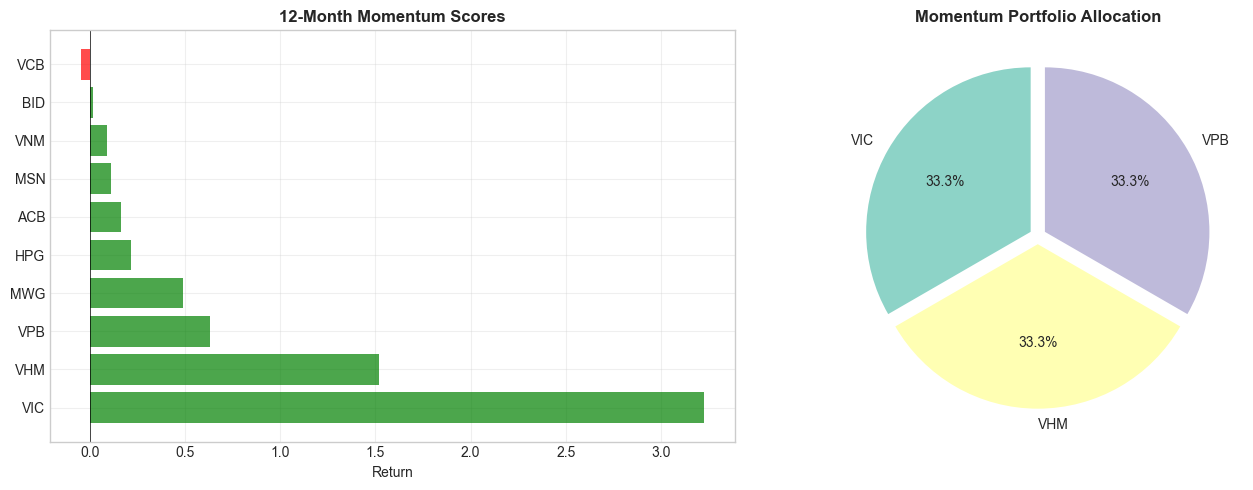

In [48]:
# Visualize momentum scores and portfolio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Momentum scores bar chart
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
symbols = [s for s, _ in sorted_scores]
momentum_vals = [sc for _, sc in sorted_scores]
colors = ['green' if v > 0 else 'red' for v in momentum_vals]

axes[0].barh(symbols, momentum_vals, color=colors, alpha=0.7)
axes[0].set_title('12-Month Momentum Scores', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].set_xlabel('Return')
axes[0].grid(True, alpha=0.3)

# Portfolio allocation pie chart
portfolio_symbols = list(weights.keys())
portfolio_weights = list(weights.values())
axes[1].pie(portfolio_weights, labels=portfolio_symbols, autopct='%1.1f%%', 
           startangle=90, colors=plt.cm.Set3.colors[:len(portfolio_symbols)],
           explode=[0.05]*len(portfolio_symbols))
axes[1].set_title('Momentum Portfolio Allocation', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

We have identified top best stocks to invest, now we can use best momentum strategies to determine when to enter and exit positions. And backtest with capital allocation based on Portfolio Allocation.

# Summary & Next Steps

In this notebook, we explored:
-  Various momentum-based trading strategies.
-  Optimized their parameters.
-  Evaluated their performance across multiple stocks.
-  Constructed a cross-sectional momentum portfolio to allocate capital effectively.

In the next notebook, we will explore strategies which use machine learning techniques to enhance trading decisions.